<a href="https://colab.research.google.com/github/scadriano/lia1_2025_2/blob/main/Aula%2008%20-%20Modelo%20para%20Identificar%20Cats%20or%20Dogs/LIA_Cats%26Dogs_com_PyTorch_ViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dogs & Cats com Vision Transformer (ViT) 🐶 🐱

Este projeto objetiva implementar um classificador de Cães e Gatos, usando um modelo pré-treinado do tipo transformer de visão, com PyTorch da biblioteca Hugging Face Transformers.

O dataset tem 1002 imagens para treino (501 dogs; 501 cats) e 200 imagens para teste (100 dogs; 100 cats), mais o duno!

## Preparação dos dados

In [40]:
# Instalar pacotes necessários
!pip install -q transformers datasets evaluate

In [41]:
# Baixar os datasets (treino) do GitHub
!wget https://github.com/scadriano/lia1_2026_1/raw/fd6124d58bd65a6a5bef162a5fe24cb3413feff8/Aula%2010%20-%20Modelo%20para%20Identificar%20Cats%20or%20Dogs/dataset_treino.zip

--2026-04-01 12:54:20--  https://github.com/scadriano/lia1_2026_1/raw/fd6124d58bd65a6a5bef162a5fe24cb3413feff8/Aula%2010%20-%20Modelo%20para%20Identificar%20Cats%20or%20Dogs/dataset_treino.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/scadriano/lia1_2026_1/fd6124d58bd65a6a5bef162a5fe24cb3413feff8/Aula%2010%20-%20Modelo%20para%20Identificar%20Cats%20or%20Dogs/dataset_treino.zip [following]
--2026-04-01 12:54:20--  https://raw.githubusercontent.com/scadriano/lia1_2026_1/fd6124d58bd65a6a5bef162a5fe24cb3413feff8/Aula%2010%20-%20Modelo%20para%20Identificar%20Cats%20or%20Dogs/dataset_treino.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP re

In [42]:
# Baixar os datasets (teste) do GitHub
!wget https://github.com/scadriano/lia1_2026_1/raw/fd6124d58bd65a6a5bef162a5fe24cb3413feff8/Aula%2010%20-%20Modelo%20para%20Identificar%20Cats%20or%20Dogs/dataset_teste.zip

--2026-04-01 12:54:22--  https://github.com/scadriano/lia1_2026_1/raw/fd6124d58bd65a6a5bef162a5fe24cb3413feff8/Aula%2010%20-%20Modelo%20para%20Identificar%20Cats%20or%20Dogs/dataset_teste.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/scadriano/lia1_2026_1/fd6124d58bd65a6a5bef162a5fe24cb3413feff8/Aula%2010%20-%20Modelo%20para%20Identificar%20Cats%20or%20Dogs/dataset_teste.zip [following]
--2026-04-01 12:54:22--  https://raw.githubusercontent.com/scadriano/lia1_2026_1/fd6124d58bd65a6a5bef162a5fe24cb3413feff8/Aula%2010%20-%20Modelo%20para%20Identificar%20Cats%20or%20Dogs/dataset_teste.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP reque

In [43]:
# Descompactar os arquivos (treino)
!unzip dataset_treino.zip

Archive:  dataset_treino.zip
replace dataset_treino/dogs/dog.99.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [44]:
# Descompactar os arquivos (teste)
!unzip dataset_teste.zip

Archive:  dataset_teste.zip
replace dataset_teste/135.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [45]:
# Importação de bibliotecas
import torch
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.datasets import ImageFolder
from transformers import ViTForImageClassification, ViTImageProcessor
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [46]:
# Definir dispositivo (GPU se disponível)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Usando dispositivo: {device}')

✅ Usando dispositivo: cuda


In [47]:
# Nome do modelo pré-treinado
model_name = "google/vit-base-patch16-224"

# Carregar processador e modelo
processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=2,                 # 2 classes: gato ou cachorro
    ignore_mismatched_sizes=True  # permite ajustar camadas finais
)
model = model.to(device)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [48]:
# Criar o dataset personalizado
class DogsAndCatsDataset(Dataset):
    def __init__(self, root_dir, processor):
        self.dataset = ImageFolder(root_dir)
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        # Pré-processar imagem para o ViT
        inputs = self.processor(images=image, return_tensors="pt")
        pixel_values = inputs['pixel_values'].squeeze()
        return pixel_values, label

In [49]:
# Diretório de treino
train_dir = './dataset_treino'

# Criar dataset completo
full_dataset = DogsAndCatsDataset(train_dir, processor)

# Dividir em treino (80%) e validação (20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Função para contar classes em um subset
def count_classes(subset):
    labels = [full_dataset.dataset.targets[i] for i in subset.indices]
    counts = {full_dataset.dataset.classes[i]: labels.count(i) for i in range(len(full_dataset.dataset.classes))}
    return counts

train_counts = count_classes(train_dataset)
val_counts = count_classes(val_dataset)

print(f'Total de imagens: {len(full_dataset)}')
print(f'Treinamento: {len(train_dataset)} imagens -> {train_counts}')
print(f'Validação: {len(val_dataset)} imagens -> {val_counts}')

# DataLoader
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

Total de imagens: 1002
Treinamento: 801 imagens -> {'cats': 411, 'dogs': 390}
Validação: 201 imagens -> {'cats': 90, 'dogs': 111}


## Treinamento

In [51]:
# Treinamento

# Configurações de treino
num_epochs = 4
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

# Loop de treinamento
for epoch in range(num_epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0

    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}')
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(pixel_values=images, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        progress_bar.set_postfix(
            loss=total_loss/(len(progress_bar)),
            accuracy=100.*correct/total
        )

    # Validação
    model.eval()
    val_correct, val_total, val_loss = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(pixel_values=images, labels=labels)
            val_loss += outputs.loss.item()
            _, predicted = outputs.logits.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    print(f"📊 Epoch {epoch+1}/{num_epochs}")
    print(f"  Treino: Loss {total_loss/len(train_loader):.4f} | Acc {100.*correct/total:.2f}%")
    print(f"  Val   : Loss {val_loss/len(val_loader):.4f} | Acc {100.*val_correct/val_total:.2f}%\n")


Epoch 1/4: 100%|██████████| 26/26 [00:36<00:00,  1.40s/it, accuracy=99.3, loss=0.0267]


📊 Epoch 1/4
  Treino: Loss 0.0267 | Acc 99.25%
  Val   : Loss 0.0081 | Acc 99.50%



Epoch 2/4: 100%|██████████| 26/26 [00:32<00:00,  1.25s/it, accuracy=99.9, loss=0.00275]


📊 Epoch 2/4
  Treino: Loss 0.0028 | Acc 99.88%
  Val   : Loss 0.0135 | Acc 99.50%



Epoch 3/4: 100%|██████████| 26/26 [00:34<00:00,  1.34s/it, accuracy=100, loss=0.000638]


📊 Epoch 3/4
  Treino: Loss 0.0006 | Acc 100.00%
  Val   : Loss 0.0062 | Acc 100.00%



Epoch 4/4: 100%|██████████| 26/26 [00:34<00:00,  1.33s/it, accuracy=100, loss=0.000348]


📊 Epoch 4/4
  Treino: Loss 0.0003 | Acc 100.00%
  Val   : Loss 0.0075 | Acc 99.50%



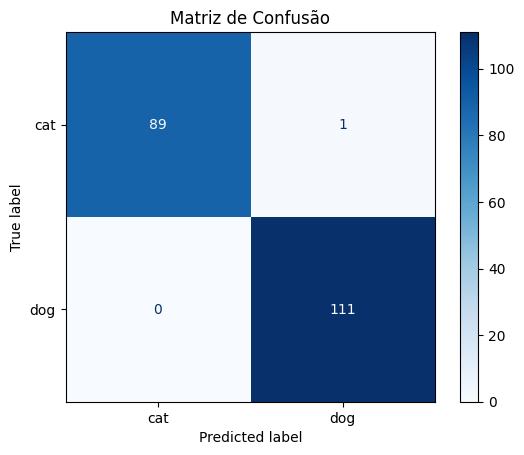

In [52]:
# Gerar a Matriz de Confusão
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(pixel_values=images, labels=labels)
        _, predicted = outputs.logits.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Matriz de confusão (0 cat; 1 dog)
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['cat','dog'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão")
plt.show()

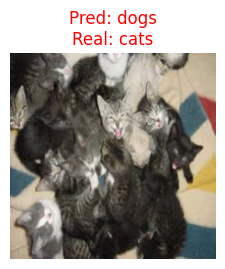

In [56]:
# Exibe as imagens classificadas incorretamente
def show_misclassified_images(model, loader, device, idx_to_class, num_images=10):
    model.eval()
    misclassified = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(pixel_values=images)
            _, preds = outputs.logits.max(1)

            mask = preds != labels
            if mask.any():
                for img, pred, label in zip(images[mask], preds[mask], labels[mask]):
                    misclassified.append((img.cpu(), pred.item(), label.item()))

            if len(misclassified) >= num_images: break

    if not misclassified:
        print("✅ Nenhuma imagem foi classificada incorretamente!")
        return

    plt.figure(figsize=(15, 5))
    for i, (img, pred, label) in enumerate(misclassified[:num_images]):
        # Desnormalizar a imagem para exibição (aproximado)
        img = img.permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min())

        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(f"Pred: {idx_to_class[pred]}\nReal: {idx_to_class[label]}", color='red')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Executar a função
idx_to_class = {v: k for k, v in full_dataset.dataset.class_to_idx.items()}
show_misclassified_images(model, val_loader, device, idx_to_class)

## Deploy - inferência em nova imagem

🐾 Classe predita: dog | Confiança: 99.97%


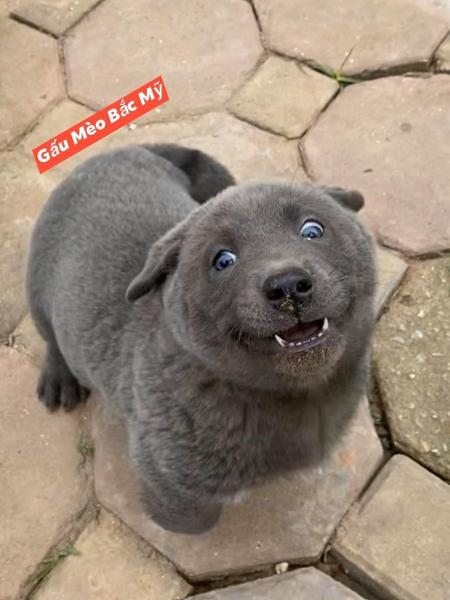

In [53]:
from PIL import Image

# Carregar imagem de teste
test_image_path = './dataset_teste/duno.jpg'
image = Image.open(test_image_path)

# Pré-processar
inputs = processor(images=image, return_tensors="pt").to(device)

# Inferência
model.eval()
with torch.no_grad():
    outputs = model(**inputs)
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
    predicted_class = torch.argmax(probabilities, dim=-1).item()

class_names = ['cat', 'dog']
predicted_label = class_names[predicted_class]
confidence = probabilities[0][predicted_class].item()

print(f"🐾 Classe predita: {predicted_label} | Confiança: {confidence:.2%}")
image